           Country  AnyType_Rate  FourTypes_Mean  BEING_Index_Mean
0            Japan      0.161892        0.068014         -0.286647
1      South Korea      0.091128        0.031805               NaN
2      Philippines      0.552468        0.342596          1.272455
3         Thailand      0.246033        0.138393          0.141846
4   United Kingdom      0.220148        0.101154          0.225120
5          Finland      0.144804        0.066295         -0.031840
6          Germany      0.094845        0.040589         -0.014095
7           Poland      0.223822        0.110533          0.068684
8            Italy      0.163852        0.087314         -0.074098
9    United States      0.219099        0.098801          0.152912
10          Canada      0.200680        0.094723          0.170097
11          Mexico      0.111659        0.057268         -0.015500
12          Brazil      0.160228        0.083154          0.141059
13          Israel      0.000000        0.000000              

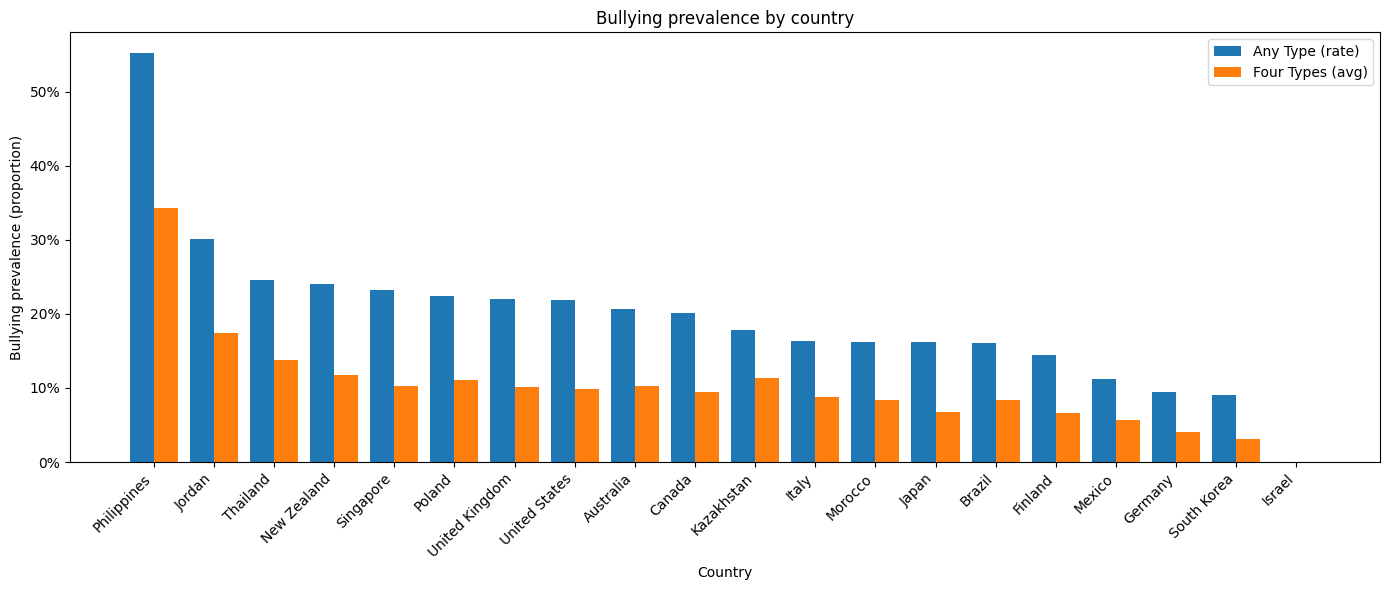

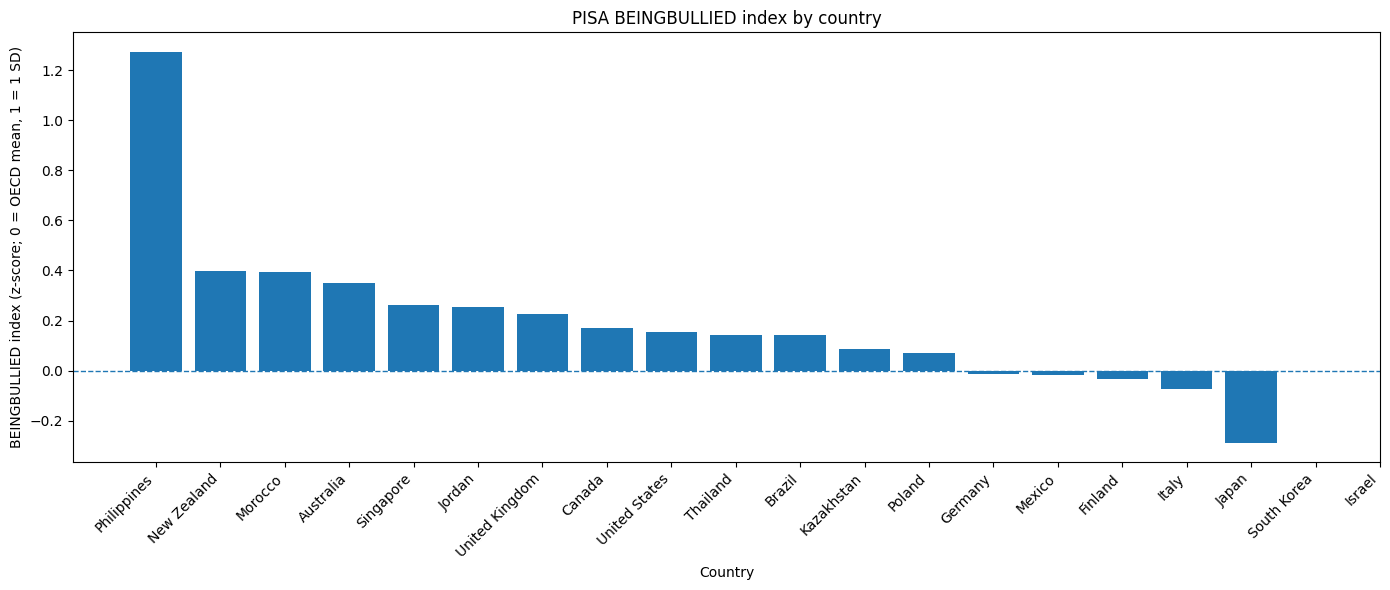

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import PercentFormatter

BEING_PATH_TEMPLATE = "../data/processed/{code}_data.pkl"
TYPES_PATH_TEMPLATE = "../data/processed/{code}_bully_types_data.pkl"

countries = [
    ("JPN", "Japan"),
    ("KOR", "South Korea"),
    ("PHL", "Philippines"),
    ("THA", "Thailand"),
    ("GBR", "United Kingdom"),
    ("FIN", "Finland"),
    ("DEU", "Germany"),
    ("POL", "Poland"),
    ("ITA", "Italy"),
    ("USA", "United States"),
    ("CAN", "Canada"),
    ("MEX", "Mexico"),
    ("BRA", "Brazil"),
    ("ISR", "Israel"),
    ("JOR", "Jordan"),
    ("MAR", "Morocco"),
    ("SGP", "Singapore"),
    ("KAZ", "Kazakhstan"),
    ("AUS", "Australia"),
    ("NZL", "New Zealand")
]

def being_index_mean(code):
    p = Path(BEING_PATH_TEMPLATE.format(code=code))
    if not p.exists(): return np.nan, 0
    df = pd.read_pickle(p)
    if "BEINGBULLIED" not in df.columns: return np.nan, 0
    s = df["BEINGBULLIED"].dropna()
    return (float(s.mean()) if len(s) else np.nan), int(len(s))

def type_rates(code):
    p = Path(TYPES_PATH_TEMPLATE.format(code=code))
    if not p.exists(): return np.nan, np.nan, 0
    df = pd.read_pickle(p)
    cols = [c for c in ["BULLY_VERBAL","BULLY_THREAT","BULLY_PHYSICAL","BULLY_RELATIONAL"] if c in df.columns]
    if not cols: return np.nan, np.nan, 0
    per_student_avg = df[cols].mean(axis=1)
    per_student_any = df[cols].max(axis=1)
    return float(per_student_avg.mean()), float(per_student_any.mean()), int(len(df))

rows = []
for code, name in countries:
    four_avg, any_rate, n_types = type_rates(code)
    idx_mean, n_being = being_index_mean(code)
    rows.append({
        "Country": name, "Code": code,
        "FourTypes_Mean": four_avg,      # proportion
        "AnyType_Rate": any_rate,        # proportion
        "BEING_Index_Mean": idx_mean,    # z-score
        "N_TYPES": n_types, "N_BEING": n_being
    })

scores = pd.DataFrame(rows)

# --- Save table ---
scores.to_csv("bullying_country_scores_fixed.csv", index=False)
print(scores[["Country","AnyType_Rate","FourTypes_Mean","BEING_Index_Mean"]])

# --- Sort for plotting proportions ---
prop_sorted = scores.sort_values("AnyType_Rate", ascending=False)

# --- Plot proportions ---
plt.figure(figsize=(14,6))
x = np.arange(len(prop_sorted))
w = 0.4
plt.bar(x - w/2, prop_sorted["AnyType_Rate"], width=w, label="Any Type (rate)")
plt.bar(x + w/2, prop_sorted["FourTypes_Mean"], width=w, label="Four Types (avg)")
plt.xticks(x, prop_sorted["Country"], rotation=45, ha="right")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.ylabel("Bullying prevalence (proportion)")
plt.xlabel("Country")
plt.title("Bullying prevalence by country")
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot BEINGBULLIED index (z-scores) separately ---
idx_sorted = scores.sort_values("BEING_Index_Mean", ascending=False)
plt.figure(figsize=(14,6))
x2 = np.arange(len(idx_sorted))
plt.bar(x2, idx_sorted["BEING_Index_Mean"])
plt.xticks(x2, idx_sorted["Country"], rotation=45, ha="right")
plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel("BEINGBULLIED index (z-score; 0 = OECD mean, 1 = 1 SD)")
plt.xlabel("Country")
plt.title("PISA BEINGBULLIED index by country")
plt.tight_layout()
plt.show()
